#  Early Warning System for Student Dropout Prediction with Explainable AI

## FlexiSAF Generative AI & Data Science (Advanced) Curriculum

---

## Introduction

FlexiSAF is an EdTech company, one of the most impactful applications of machine learning is identifying students at risk of dropping out **before** it happens. An **Early Warning System (EWS)** uses historical academic and demographic data to predict future student outcomes, enabling proactive intervention.

In this notebook, we will:
1. **Explore** the UCI "Predict Students' Dropout and Academic Success" dataset
2. **Build** an XGBoost classifier to predict student dropout vs. graduation
3. **Evaluate** using Precision, Recall, F1-Score, and a Confusion Matrix
4. **Explain** predictions using **SHAP** (SHapley Additive exPlanations) — so teachers know *why* a student is flagged, not just *that* they are

> **Why Explainability Matters:** If a system tells a teacher "Student A is at 85% risk," the immediate question is **"Why?"** SHAP answers that question with concrete, feature-level explanations — enabling personalized, data-driven interventions.

### Dataset Source
- **UCI Machine Learning Repository**: [Predict Students' Dropout and Academic Success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success)
- 4,424 students with 36 features covering demographics, socioeconomic background, and academic performance

In [15]:
#  IMPORTS & CONFIGURATION
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score
)

from xgboost import XGBClassifier

import shap

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
np.random.seed(42)

print("All libraries loaded successfully")

All libraries loaded successfully


---
## 1. Data Loading & Initial Exploration

The dataset uses a **semicolon** (`;`) separator and has some quirks in column names (e.g., tab characters). We'll clean those up during loading.

In [16]:
# LOAD AND INSPECT THE DATA

df = pd.read_csv('data.csv', sep=';')

# Clean column names: strip whitespace and tab characters
# The original CSV has a tab character in 'Daytime/evening attendance'
df.columns = df.columns.str.strip().str.replace('\t', '', regex=False)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names ({len(df.columns)} total):")
for i, col in enumerate(df.columns):
    print(f"  {i:2d}. {col}")

print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
display(df.head())

# Data types and info
print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
df.info()

# Summary statistics
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
display(df.describe())

# Missing values check
missing = df.isnull().sum()
total_missing = missing.sum()
if total_missing == 0:
    print("\n No missing values found in the dataset.")
else:
    print(f"\n Total missing values: {total_missing}")
    print(missing[missing > 0])

DATASET OVERVIEW
Shape: 4,424 rows × 37 columns

Column names (37 total):
   0. Marital status
   1. Application mode
   2. Application order
   3. Course
   4. Daytime/evening attendance
   5. Previous qualification
   6. Previous qualification (grade)
   7. Nacionality
   8. Mother's qualification
   9. Father's qualification
  10. Mother's occupation
  11. Father's occupation
  12. Admission grade
  13. Displaced
  14. Educational special needs
  15. Debtor
  16. Tuition fees up to date
  17. Gender
  18. Scholarship holder
  19. Age at enrollment
  20. International
  21. Curricular units 1st sem (credited)
  22. Curricular units 1st sem (enrolled)
  23. Curricular units 1st sem (evaluations)
  24. Curricular units 1st sem (approved)
  25. Curricular units 1st sem (grade)
  26. Curricular units 1st sem (without evaluations)
  27. Curricular units 2nd sem (credited)
  28. Curricular units 2nd sem (enrolled)
  29. Curricular units 2nd sem (evaluations)
  30. Curricular units 2nd sem 

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



DATA TYPES
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                  

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000



 No missing values found in the dataset.


---
## 2. Exploratory Data Analysis (EDA)

Before building a model, it's essential to understand the data. We'll examine:
1. The **distribution of the target variable** (Dropout / Graduate / Enrolled)
2. **Feature correlations** to identify the strongest predictors
3. **Key academic metrics** across outcome categories

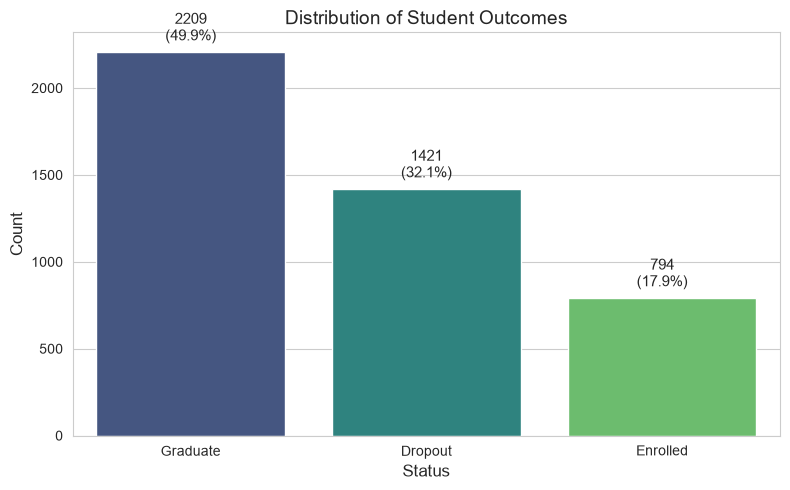


Target value counts:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [17]:
# EDA PLOT 1: Target Variable Distribution

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Target', order=df['Target'].value_counts().index,
                   palette='viridis')
plt.title('Distribution of Student Outcomes', fontsize=14)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Annotate bars with counts and percentages
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = f'{100 * count / total:.1f}%'
    ax.annotate(f'{count}\n({pct})',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11,
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

print("\nTarget value counts:")
print(df['Target'].value_counts())

**Insight:** The dataset has three classes:
- **Graduate** (~50%) — successfully completed the program
- **Dropout** (~32%) — left before completing
- **Enrolled** (~18%) — still in the program (outcome unknown)

Since 'Enrolled' students have no definitive outcome yet, we'll **exclude them** and focus on a clear binary prediction: **Dropout vs. Graduate**.

Top 15 features most correlated with student outcome:
   1. Curricular units 2nd sem (approved)                (|r| = 0.624)
   2. Curricular units 2nd sem (grade)                   (|r| = 0.567)
   3. Curricular units 1st sem (approved)                (|r| = 0.529)
   4. Curricular units 1st sem (grade)                   (|r| = 0.485)
   5. Tuition fees up to date                            (|r| = 0.410)
   6. Scholarship holder                                 (|r| = 0.298)
   7. Age at enrollment                                  (|r| = 0.243)
   8. Debtor                                             (|r| = 0.241)
   9. Gender                                             (|r| = 0.229)
  10. Application mode                                   (|r| = 0.222)
  11. Curricular units 2nd sem (enrolled)                (|r| = 0.176)
  12. Curricular units 1st sem (enrolled)                (|r| = 0.156)
  13. Admission grade                                    (|r| = 0.121)
  14. Displaced        

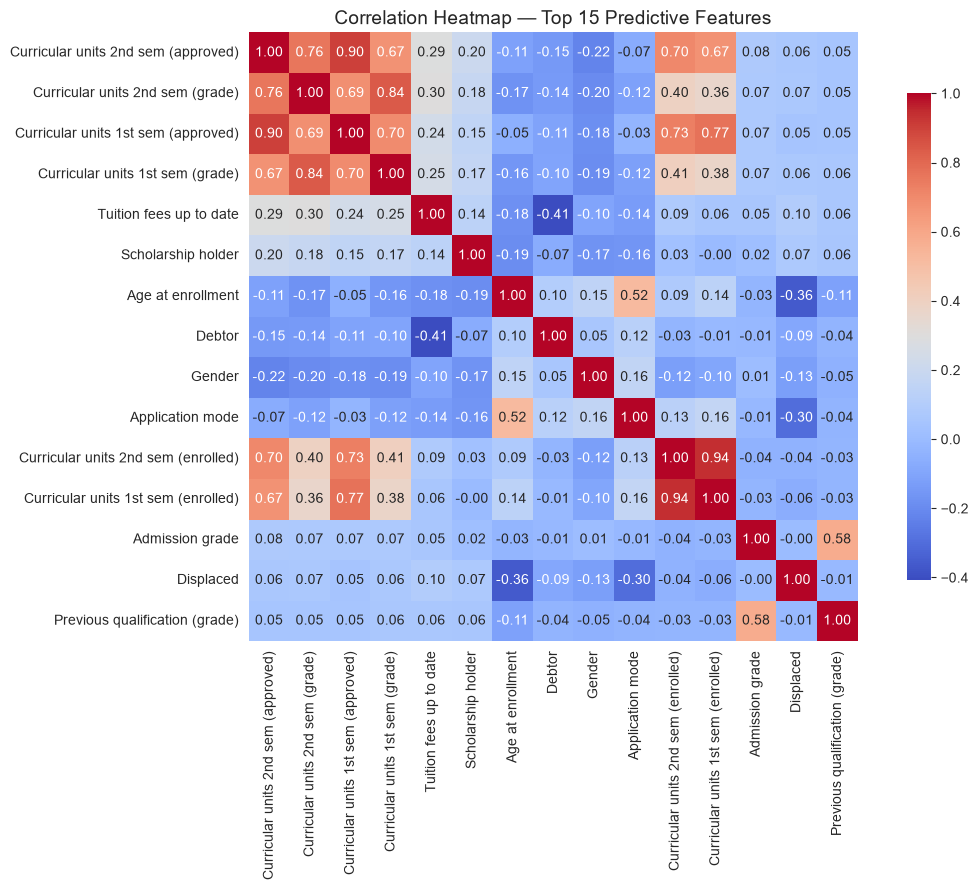

In [18]:
# EDA PLOT 2: Correlation Heatmap (Top 15 Features)

# Temporarily encode the target to compute correlations
temp_df = df.copy()
temp_df['Target_Encoded'] = temp_df['Target'].map(
    {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
)

# Find the top 15 features most correlated with the target
correlations = temp_df.corr(numeric_only=True)['Target_Encoded'].abs()
correlations = correlations.sort_values(ascending=False)
top_features = correlations.index[1:16]  # Exclude target itself

print("Top 15 features most correlated with student outcome:")
for i, feat in enumerate(top_features, 1):
    print(f"  {i:2d}. {feat:50s} (|r| = {correlations[feat]:.3f})")

# Plot the heatmap of these top features
plt.figure(figsize=(12, 9))
sns.heatmap(
    temp_df[top_features].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    square=True, cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Top 15 Predictive Features', fontsize=14)
plt.tight_layout()
plt.show()

**📊 Insight:** Curricular units in both semesters (especially **approved units** and **grades**) dominate the correlation rankings. This makes intuitive sense: students who pass more courses with higher grades are far less likely to drop out. These will be the model's strongest signals.

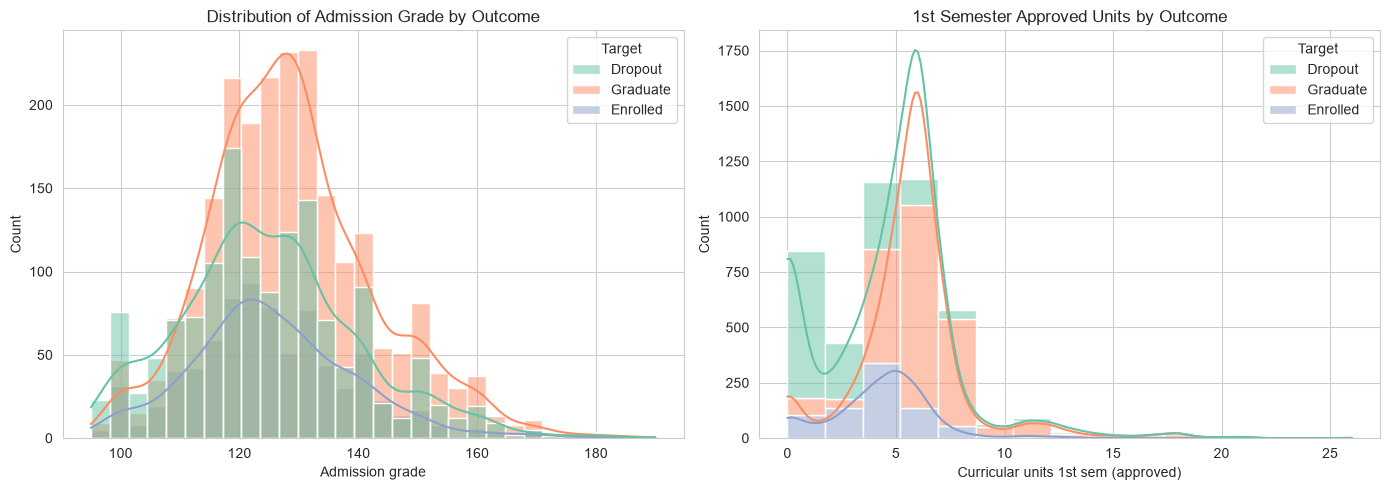

In [19]:
# EDA PLOT 3: Distribution of Key Academic Features by Outcome

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Admission Grade
sns.histplot(data=df, x='Admission grade', hue='Target',
             kde=True, palette='Set2', bins=30, ax=axes[0])
axes[0].set_title('Distribution of Admission Grade by Outcome', fontsize=12)

# Plot B: 1st Semester Approved Units
sns.histplot(data=df, x='Curricular units 1st sem (approved)', hue='Target',
             kde=True, palette='Set2', bins=15, multiple='stack', ax=axes[1])
axes[1].set_title('1st Semester Approved Units by Outcome', fontsize=12)

plt.tight_layout()
plt.show()

**📊 Insight:** Students who drop out tend to have **fewer approved curricular units** in the 1st semester. Admission grade shows more overlap between groups it's a weaker predictor on its own compared to first-semester performance.

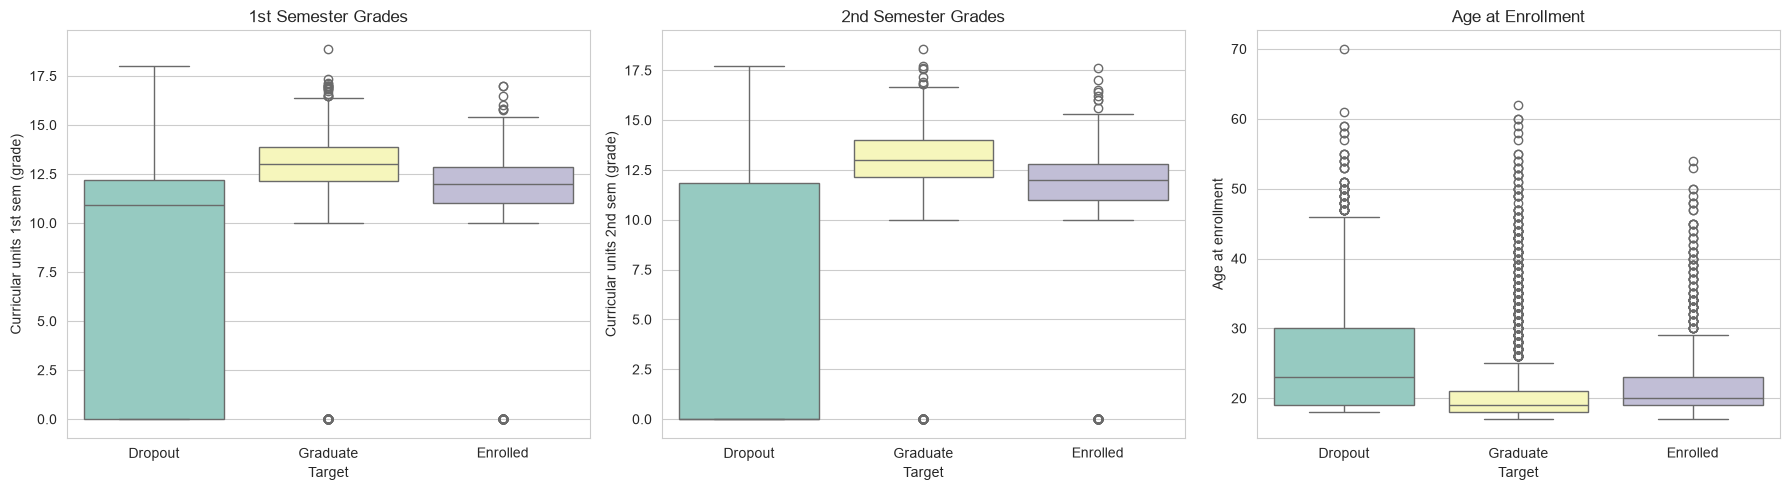

In [20]:
# EDA PLOT 4: Box Plots of Key Features by Outcome

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1st Semester Grades
sns.boxplot(data=df, x='Target', y='Curricular units 1st sem (grade)',
            palette='Set3', ax=axes[0])
axes[0].set_title('1st Semester Grades', fontsize=12)

# 2nd Semester Grades
sns.boxplot(data=df, x='Target', y='Curricular units 2nd sem (grade)',
            palette='Set3', ax=axes[1])
axes[1].set_title('2nd Semester Grades', fontsize=12)

# Age at Enrollment
sns.boxplot(data=df, x='Target', y='Age at enrollment',
            palette='Set3', ax=axes[2])
axes[2].set_title('Age at Enrollment', fontsize=12)

plt.tight_layout()
plt.show()

**📊 Insight:** 
- Dropouts have **significantly lower median grades** in both semesters a clear academic distress signal
- Older students at enrollment appear slightly more prone to dropping out, possibly due to competing life responsibilities (work, family)
- These patterns validate that an ML model can learn meaningful distinctions between successful and at-risk students

---
## 3. Data Preprocessing

Before training the model, we need to:

| Step | What | Why |
|---|---|---|
| 1 | Remove 'Enrolled' students | Their outcome is unknown, can't train on them |
| 2 | Encode Target | Dropout = **1** (at-risk, the class we want to detect) |
| 3 | Train/Test split (80/20) | Evaluate on unseen data, stratified to keep class ratio |
| 4 | Feature scaling | StandardScaler for consistent feature ranges |

In [21]:
# CELL: DATA PREPROCESSING

# Step 1: Filter to binary classification — remove 'Enrolled' students
df_binary = df[df['Target'] != 'Enrolled'].copy()
print(f"After removing 'Enrolled': {len(df_binary):,} students remain")
print(f"  - Graduate: {(df_binary['Target'] == 'Graduate').sum()}")
print(f"  - Dropout:  {(df_binary['Target'] == 'Dropout').sum()}")

# Step 2: Encode Target → Dropout=1 (At-Risk), Graduate=0 (Safe)
df_binary['Target'] = df_binary['Target'].map({'Dropout': 1, 'Graduate': 0})

# Separate features (X) and target (y)
X = df_binary.drop(columns=['Target'])
y = df_binary['Target']

# Step 3: Train/Test Split (80/20, stratified, reproducible)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 4: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)      
X_test_scaled  = scaler.transform(X_test)            


feature_names = X.columns.tolist()
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=feature_names)

print(f"\nTraining set: {X_train_df.shape[0]} samples")
print(f"Test set:     {X_test_df.shape[0]} samples")
print(f"Features:     {X_train_df.shape[1]}")

After removing 'Enrolled': 3,630 students remain
  - Graduate: 2209
  - Dropout:  1421

Training set: 2904 samples
Test set:     726 samples
Features:     36


---
## 4. Model Training, XGBoost (Ensemble Learning)

### Why XGBoost?
**XGBoost** (eXtreme Gradient Boosting) is an advanced **ensemble algorithm** that builds hundreds of decision trees sequentially, where each new tree corrects the errors of the previous ones. It's the go-to choice for tabular data because:

-  Handles class imbalance via `scale_pos_weight`
-  Built-in regularization prevents overfitting
-  Natively provides feature importance
-  Compatible with SHAP's `TreeExplainer` for fast explanations

> **Alternative Ensemble Methods:**
> - **Random Forest**:  trains trees in parallel (bagging) rather than sequentially (boosting). Simpler but often slightly less accurate.
> - **Stacking/Voting Ensemble**: combines XGBoost, Random Forest, and Logistic Regression. Can squeeze out extra performance in production.
> - **LightGBM / CatBoost**: other gradient boosting libraries with different optimization strategies.

In [22]:
# CELL: TRAIN XGBOOST MODEL

# Calculate class imbalance ratio for scale_pos_weight

n_graduate = (y_train == 0).sum()  # Majority class
n_dropout  = (y_train == 1).sum()  # Minority class (what we want to detect)
imbalance_ratio = n_graduate / n_dropout

print(f"Class distribution in training set:")
print(f"  Graduate (0): {n_graduate} ({100 * n_graduate / len(y_train):.1f}%)")
print(f"  Dropout  (1): {n_dropout}  ({100 * n_dropout / len(y_train):.1f}%)")
print(f"  Imbalance ratio (scale_pos_weight): {imbalance_ratio:.2f}")

# Initialize and configure the XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=200,              # Number of boosting rounds (trees)
    max_depth=6,                   # Maximum tree depth (controls complexity)
    learning_rate=0.1,             # Step size shrinkage (lower = more robust)
    scale_pos_weight=imbalance_ratio,  # Compensate for class imbalance
    random_state=42,               # Reproducibility
    use_label_encoder=False,       # Suppress deprecation warning
    eval_metric='logloss'          # Binary cross-entropy for evaluation
)

# Train the model
print("\nTraining XGBoost model...")
xgb_model.fit(X_train_df, y_train)
print(" Model training complete.")

Class distribution in training set:
  Graduate (0): 1767 (60.8%)
  Dropout  (1): 1137  (39.2%)
  Imbalance ratio (scale_pos_weight): 1.55

Training XGBoost model...
 Model training complete.


---
## 5. Model Evaluation

For an **Early Warning System**, understanding evaluation metrics in the educational context is critical:

| Metric | What it measures | In our context |
|---|---|---|
| **Precision** (Dropout) | Of all students *flagged* as at-risk, how many actually dropped out? | High precision → fewer false alarms (less wasted intervention effort) |
| **Recall** (Dropout) | Of all students who *actually* dropped out, how many did we catch? | High recall → fewer students slip through the cracks |
| **F1-Score** | Harmonic mean of Precision & Recall | Balances both concerns |

> ** In early warning, Recall for Dropout is the most critical metric.** A false positive (flagging a student who would have graduated) results in unnecessary but harmless extra support. A false negative (missing a student who actually drops out) is a missed opportunity to intervene.

CLASSIFICATION REPORT
                   precision    recall  f1-score   support

  Graduate (Safe)       0.94      0.93      0.94       442
Dropout (At-Risk)       0.90      0.90      0.90       284

         accuracy                           0.92       726
        macro avg       0.92      0.92      0.92       726
     weighted avg       0.92      0.92      0.92       726

DROPOUT (AT-RISK) CLASS METRICS
  Precision : 0.895  (of flagged students, 89.5% actually dropped out)
  Recall    : 0.905  (caught 90.5% of actual dropouts)
  F1-Score  : 0.900
  ROC-AUC   : 0.969


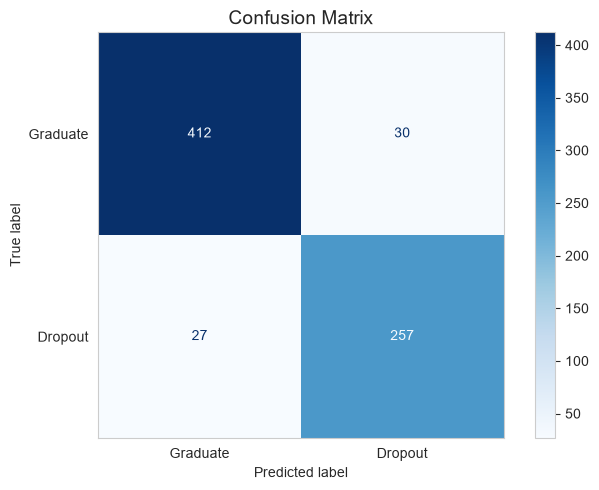


Confusion Matrix Breakdown:
   True Negatives  (correctly identified Safe):     412
    False Positives (flagged but actually Safe):    30
   False Negatives (MISSED at-risk students):       27
   True Positives  (correctly caught at-risk):      257


In [23]:
# CELL: MODEL EVALUATION

# Generate predictions on the test set
y_pred = xgb_model.predict(X_test_df)
y_pred_proba = xgb_model.predict_proba(X_test_df)[:, 1]  # Probability of Dropout

# Classification Report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    y_test, y_pred,
    target_names=['Graduate (Safe)', 'Dropout (At-Risk)']
))

# Key metrics for the Dropout class
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_proba)

print("=" * 60)
print("DROPOUT (AT-RISK) CLASS METRICS")
print("=" * 60)
print(f"  Precision : {prec:.3f}  (of flagged students, {prec*100:.1f}% actually dropped out)")
print(f"  Recall    : {rec:.3f}  (caught {rec*100:.1f}% of actual dropouts)")
print(f"  F1-Score  : {f1:.3f}")
print(f"  ROC-AUC   : {auc:.3f}")

# Confusion Matrix 
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Graduate', 'Dropout']
)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Confusion Matrix', fontsize=14)
plt.grid(False)  # Cleaner look without grid
plt.tight_layout()
plt.show()

# Explain the quadrants
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"   True Negatives  (correctly identified Safe):     {tn}")
print(f"    False Positives (flagged but actually Safe):    {fp}")
print(f"   False Negatives (MISSED at-risk students):       {fn}")
print(f"   True Positives  (correctly caught at-risk):      {tp}")

---
## 6. SHAP Explainability:  Making the Model Transparent

### What is SHAP?
**SHAP** (SHapley Additive exPlanations) uses game theory to assign each feature an "importance value" for each individual prediction. It answers:
- **Globally**: Which features matter most *overall*?
- **Locally**: For *this specific student*, why was the prediction Dropout?

This is essential for FlexiSAF because:
- Teachers need to understand *why* a student is flagged to take the right action
- Parents need clear, transparent explanations
- School policies require accountability and fairness in automated decisions

SHAP values computed for 726 test samples.
Shape: (726, 36)


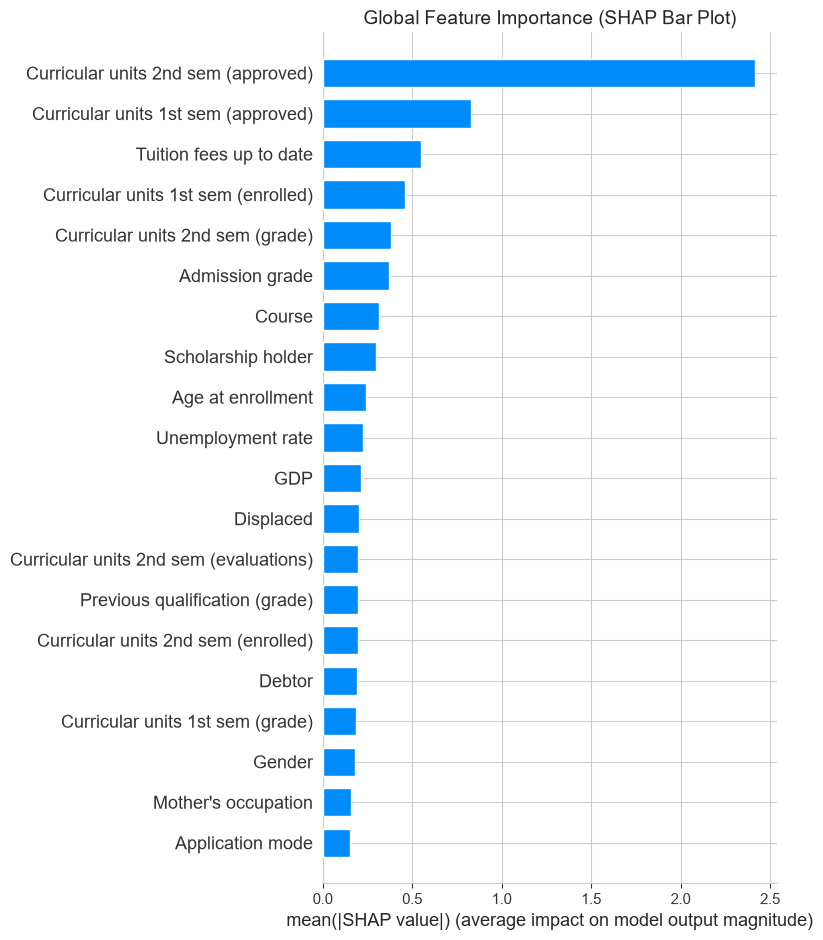

In [24]:
# CELL: SHAP — GLOBAL FEATURE IMPORTANCE

# Initialize SHAP's TreeExplainer (optimized for tree-based models)
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for all test samples
shap_values = explainer(X_test_df)

print(f"SHAP values computed for {len(X_test_df)} test samples.")
print(f"Shape: {shap_values.values.shape}")

# SHAP Bar Plot: Global Feature Importance

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df, plot_type='bar', show=False)
plt.title('Global Feature Importance (SHAP Bar Plot)', fontsize=14)
plt.tight_layout()
plt.show()

**📊 Interpretation of the Bar Plot:**
The features at the top have the **greatest overall impact** on the model's predictions. For a school administrator, this reveals which data points are most valuable to collect and monitor focus on the top features when designing intervention programs.

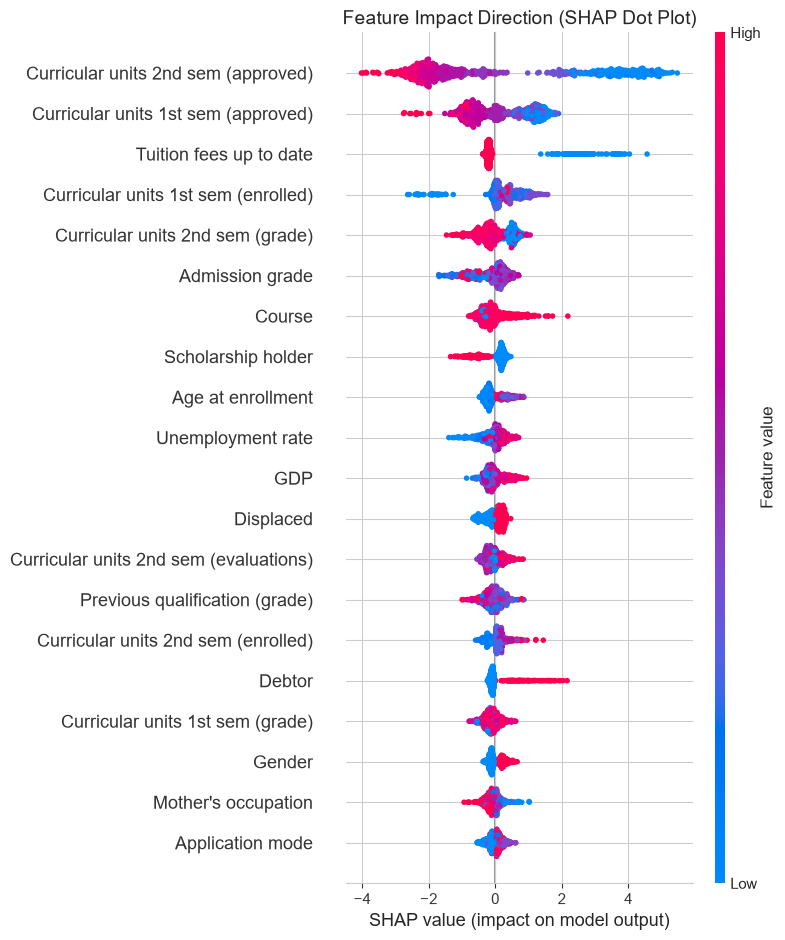

In [25]:
# CELL: SHAP DOT PLOT — Directional Feature Impact

# The dot plot shows HOW each feature affects predictions:
# - Each dot = one student
# - X-axis = SHAP value (positive → pushes toward Dropout, negative → toward Graduate)
# - Color = feature value (red = high, blue = low)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title('Feature Impact Direction (SHAP Dot Plot)', fontsize=14)
plt.tight_layout()
plt.show()

**📊 How to read the Dot Plot:**
- **Red dots on the right** = a *high* feature value pushes prediction toward Dropout
- **Blue dots on the right** = a *low* feature value pushes prediction toward Dropout

For example, if "Curricular units 2nd sem (approved)" shows blue dots (low values) clustered on the right (positive SHAP), it means: *students who approved few 2nd-semester units are strongly predicted as dropouts*. This is actionable: teachers should watch for students failing multiple courses.

INDIVIDUAL STUDENT EXPLANATION
Student index in test set: 7
Actual outcome:     DROPOUT
Predicted outcome:  DROPOUT (probability: 99.5%)

The waterfall plot below shows WHY this student was flagged:


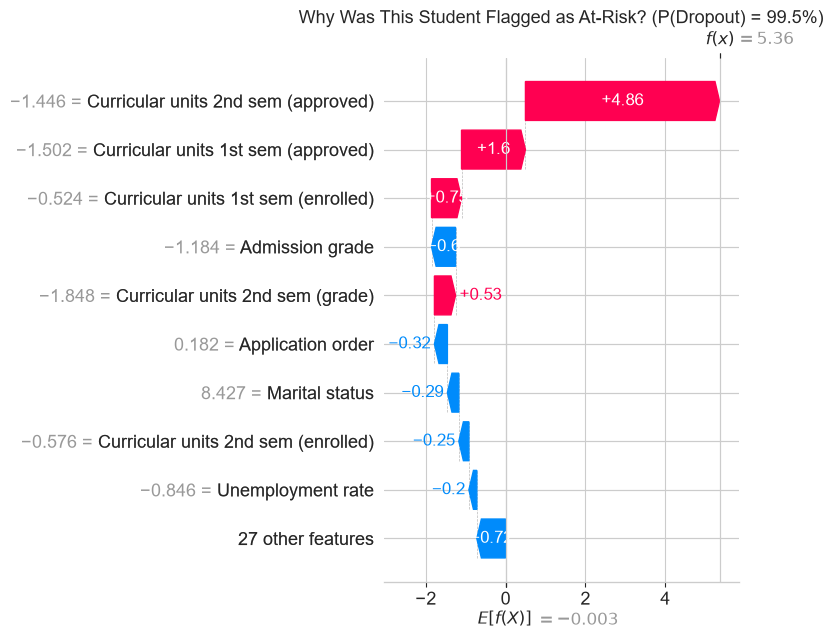

In [26]:
# CELL: SHAP WATERFALL PLOT — Explaining a Single Student

# Find a student who was correctly identified as Dropout (True Positive)
tp_indices = np.where((y_test.values == 1) & (y_pred == 1))[0]
student_idx = tp_indices[0]  # Pick the first true positive

# Get the model's predicted probability for this student
student_prob = y_pred_proba[student_idx]

print(f"=" * 60)
print(f"INDIVIDUAL STUDENT EXPLANATION")
print(f"=" * 60)
print(f"Student index in test set: {student_idx}")
print(f"Actual outcome:     DROPOUT")
print(f"Predicted outcome:  DROPOUT (probability: {student_prob:.1%})")
print(f"\nThe waterfall plot below shows WHY this student was flagged:")

# Generate waterfall plot
plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_values[student_idx], show=False)
plt.title(f'Why Was This Student Flagged as At-Risk? (P(Dropout) = {student_prob:.1%})',
          fontsize=13)
plt.tight_layout()
plt.show()

**How to read the Waterfall Plot:**
- The plot starts from the **base value** (average prediction for all students)
- Each row shows a feature and how it pushed the prediction **up** (red, toward Dropout) or **down** (blue, toward Graduate)
- The **f(x)** value at the top is the final model output for this student

**What a teacher/counselor can learn:** Instead of just seeing "Student A is at 85% risk," they can see: *"This student is at risk primarily because they approved 0 curricular units in the 2nd semester, had low 1st-semester grades, and their tuition fees are not up to date."* This enables targeted, empathetic conversations.

---

### Real-time Risk Scoring
Deploy the model as an API endpoint. As semester grades or attendance records are updated in SAFSIMS, the system automatically recalculates each student's risk score in real time.

### Teacher Dashboard with SHAP Explanations
Build a module in the teacher portal that:
- Highlights at-risk students with a color-coded risk gauge
- Shows the **top 3 reasons** why each student was flagged (derived from SHAP waterfall data)
- Example display: *" Flagged primarily due to: (1) Low 1st-semester grades, (2) Tuition fees not current, (3) High number of unapproved units"*

###  Automated Alerts
- Send SMS/email alerts to **guidance counselors** when a student crosses a critical risk threshold (e.g., >70% dropout probability)
- Send gentler notifications to **parents** encouraging engagement with the school

###  Mid-Semester Checkpoints
Run batch predictions at **mid-semester** using continuous assessment scores. This gives teachers a 6-8 week window to intervene before final exams.

###  Ethical & Privacy Considerations
- **Data Privacy**: Anonymize data in analytics dashboards. Comply with local data protection regulations.
- **Algorithmic Bias**: Regularly audit the model for bias against demographic groups (gender, nationality, socioeconomic status).
- **Human-in-the-Loop**: The model is an *advisor*, not an absolute judge. Teachers must apply context, empathy, and professional judgment alongside the model's recommendations.
- **Transparency**: Students and parents should know the system exists and have the right to understand or challenge their risk assessment.

---
## 8. Conclusion

In this notebook, we:

1.  **Explored** the UCI student dataset identifying curricular performance as the strongest predictor of dropout
2.  **Built** an XGBoost ensemble model that predicts dropout with strong Recall (catching most at-risk students)
3.  **Evaluated** with Precision, Recall, F1-Score, ROC-AUC, and a Confusion Matrix
4.  **Explained** predictions using SHAP — both globally (which features matter most) and locally (why a specific student was flagged)

### Key Takeaway
By combining **accurate prediction** (ensemble learning) with **transparent explanations** (SHAP), this system moves beyond a black-box model into a tool that educators can trust, understand, and act on.